# Cython

Загружаю Cython как расширение, чтобы использовать в здешней тетрадке.

In [1]:
%load_ext cython

### Привет, Cython!

Простой пример - это пока не про "Привет, мир!", а про ещё более простые действия вроде присваивание значения переменной.

In [2]:
%%cython -a
# -a == --annotate

a = 1

Это простыня, которую даже разбирать не хочется, но можно скормить нейронке (пусть она обжёвывает).

Ладно, можно запустить (за здравие) "приветственную" функцию, взятую из [документации](https://cython.readthedocs.io/en/latest/src/quickstart/build.html).

In [3]:
%%cython

def say_hello_to(name):
    print(f"Hello {name}!")

say_hello_to("Cython")

Hello Cython!


Вроде работает и это чистая Пайтон функция, здесь не видно чего-то сайтонического, а значит это вполне подтверждает, что *Cython умеет обрабатывать Python код*.

Теперь сравню разные имплементации функции "сложения всех чисел с 1 по `n`".

In [4]:
# Pure Python
def sum_py(n: int) -> int:
    s = 0
    for i in range(1, n + 1):
        s += i
    return s

In [5]:
%%cython

# Pure Python passed through Cython
def sum_cypy(n: int) -> int:
    s = 0
    for i in range(1, n + 1):
        s += i
    return s

In [6]:
%%cython

# Cython function - similar, but not the same
def sum_cy(int n):  # here `int` is not a Python int
    cdef int i            # `int i;`
    cdef long long s = 0  # `long long s = 0;` 
    for i in range(n):
        s += i
    return s

Функция `sum_cy` написана на Cython и она не тождественная предыдущим функциям, потому что в ней переменные объявлены с типами ограниченных размеров, которые больше про Си, чем про Пайтон.

Замеры быстродействия и пока нет дела до возможного переполнения - на этих функциях проверять это будет дорого.

In [7]:
nth = 10_000

# -n -> number of runs per round
# -r -> number of rounds

%timeit -n 1000 -r 10 sum_py(nth)
%timeit -n 1000 -r 10 sum_cypy(nth)
%timeit -n 1000 -r 10 sum_cy(nth)

187 μs ± 4.36 μs per loop (mean ± std. dev. of 10 runs, 1,000 loops each)
154 μs ± 1.41 μs per loop (mean ± std. dev. of 10 runs, 1,000 loops each)
1.41 μs ± 53.8 ns per loop (mean ± std. dev. of 10 runs, 1,000 loops each)


Чистая питоновская функция, прогнанная через Сайтон, выполняется чуть быстро, но всё же одного порядка и выигрыш чучуточный. А вот сайтоновская функция показывает впечатляющий полёт!

### Переполнение

Кто прогал на Си, тот в [летающем цирке](https://en.wikipedia.org/wiki/Monty_Python%27s_Flying_Circus) не смеётся и знает, что типы в Си имеют ограничения на размер. Проще всего посмотреть на факториале и я позаимствую реализацию из [своей же заметки](https://github.com/stankudrow/Learning-Python-Packaging/blob/main/notes/ch02/extra/cython.ipynb). 

In [8]:
%%cython

cimport cython

def factorial_cy(int n):
    if n < 0:
        msg = f"{n} < 0"
        raise ValueError(msg) from None
    if n < 2:
        return 1
    cdef int i
    cdef long long f = 1
    for i in range(2, n + 1):  # n is not expected to be overflown
        with cython.overflowcheck(True):
            f *= i
    return f

In [9]:
for n in range(1, 22):
    print(f"{n:<2}! = {factorial_cy(n)}")

1 ! = 1
2 ! = 2
3 ! = 6
4 ! = 24
5 ! = 120
6 ! = 720
7 ! = 5040
8 ! = 40320
9 ! = 362880
10! = 3628800
11! = 39916800
12! = 479001600
13! = 6227020800
14! = 87178291200
15! = 1307674368000
16! = 20922789888000
17! = 355687428096000
18! = 6402373705728000
19! = 121645100408832000
20! = 2432902008176640000
21! = -4249290049419214848


Длинное, пусть даже дважды, целое не вместило `21!` (на моей машине, на вашей может быть по-другому). Если нужны факториалы быстро и от небольших целых, которые уместятся в `long long` на вашей машине, то здорово, но вообще это решение сомнительное и не "окейное". Но почему?

- факториал повалится на больших числах - это уже обсуждено и само это может быть громадным ограничением
- можно "сховать" (закэшировать) значения от "чистопайтоновской" (так!) функции и вытаскивать значения из словаря-скрытня...давайте посмотрим насколько это может быть действенно.

In [10]:
# cache table -> dynamic programming (DP) trick
_dp: list[int] = [1, 1, 2]  # 0! = 1, 1! = 1, 2! = 2

def factorial_py(n: int) -> int:
    if n < 0:
        msg = f"{n} < 0"
        raise ValueError(msg) from None
    siz = len(_dp)
    if n < siz:
        return _dp[n]
    _dp.extend([None for _ in range(n - siz + 1)])
    start = siz - 1
    f = _dp[start]
    for i in range(siz, n + 1):
        f *= i
        _dp[i] = f
    return _dp[-1]


for n in range(1, 22):
    print(f"{n:<2}! = {factorial_py(n)}")

print(f"cache -> {_dp}")

1 ! = 1
2 ! = 2
3 ! = 6
4 ! = 24
5 ! = 120
6 ! = 720
7 ! = 5040
8 ! = 40320
9 ! = 362880
10! = 3628800
11! = 39916800
12! = 479001600
13! = 6227020800
14! = 87178291200
15! = 1307674368000
16! = 20922789888000
17! = 355687428096000
18! = 6402373705728000
19! = 121645100408832000
20! = 2432902008176640000
21! = 51090942171709440000
cache -> [1, 1, 2, 6, 24, 120, 720, 5040, 40320, 362880, 3628800, 39916800, 479001600, 6227020800, 87178291200, 1307674368000, 20922789888000, 355687428096000, 6402373705728000, 121645100408832000, 2432902008176640000, 51090942171709440000]


Вроде отпахивает как следует, а теперь проверка производительности и посчитаю вычисление в обратную с 20 и по 0, чтобы уже на 20 заложить все предшествующие значения. Если ячейка выше была исполнена (а с чего бы нет), то кэш уже прогрет и последующие замеры не будут учитывать наполнение таблицы сохраняемых значений.

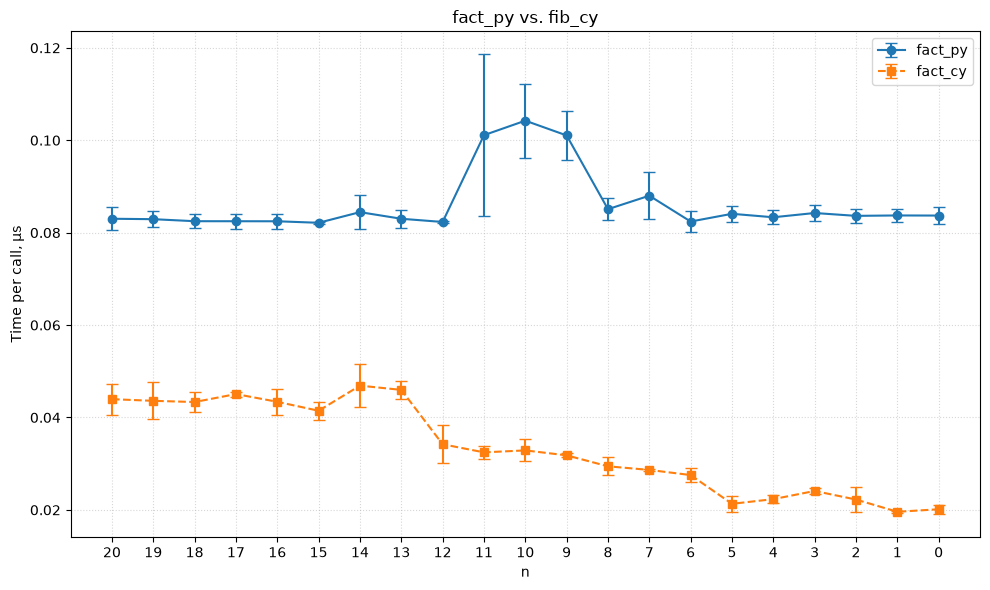

In [11]:
import functools
import timeit
import statistics
from collections.abc import Iterable

import matplotlib.pyplot as plt


def measure(f: Callable, *, number: int = 1000, repeat: int = 10) -> tuple[float, float]:
    res = timeit.repeat(f, number=number, repeat=repeat)
    mean = statistics.mean(res) / number * 1e6
    std = statistics.stdev(res) / number * 1e6
    return (mean, std)  # in microseconds


def plot_factorials(nums: Iterable[int]) -> None:
    nums = list(nums)

    results_py: list[tuple[float, float]] = [
        measure(functools.partial(factorial_py, n))
        for n in nums
    ]
    means_py = [r[0] for r in results_py]
    stds_py = [r[1] for r in results_py]

    results_cy: list[tuple[float, float]] = [
        measure(functools.partial(factorial_cy, n))
        for n in nums
    ]
    means_cy = [r[0] for r in results_cy]
    stds_cy = [r[1] for r in results_cy]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(nums, means_py, yerr=stds_py, fmt='o-', label='fact_py', capsize=4, linewidth=1.5, markersize=6)
    ax.errorbar(nums, means_cy, yerr=stds_cy, fmt='s--', label='fact_cy', capsize=4, linewidth=1.5, markersize=6)
    
    ax.set_xlabel('n')
    ax.set_ylabel('Time per call, µs')
    ax.set_title('fact_py vs. fib_cy')
    ax.set_xticks(nums)
    ax.invert_xaxis()
    
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()


nums = list(range(20, -1, -1))
plot_factorials(nums)

И снова Сайтон обогнал Пайтон, но не нужно спешить с радостью и впихивать Сайтон куда угодно и без мыла. Что если прогнать другой ряд чисел?

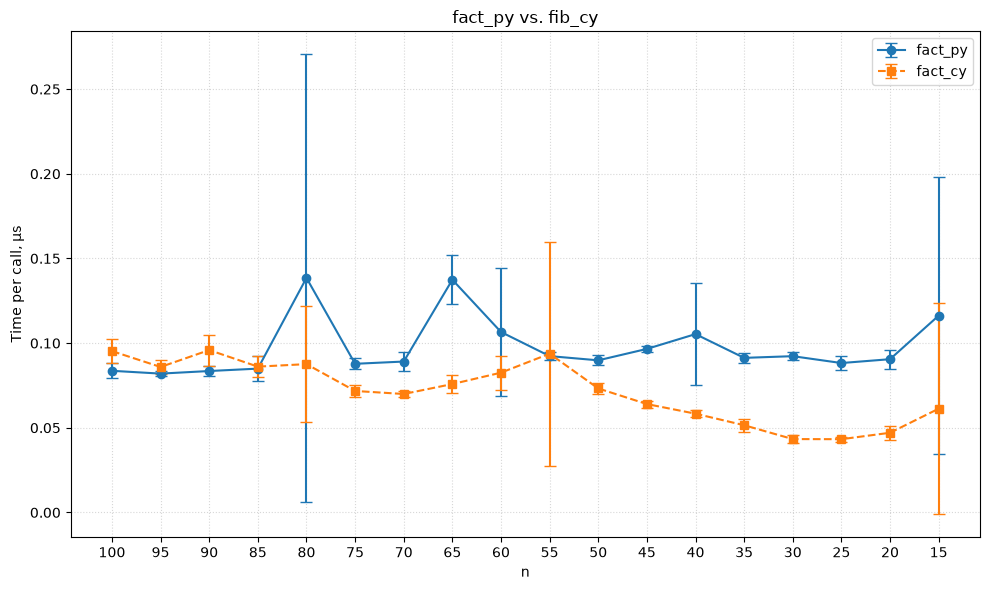

In [12]:
nums = list(range(100, 10, -5))
plot_factorials(nums)

Здесь важно уточнить, что нужно посмотреть несколько запусков и отрисовки графиков - выдатки (результаты) разнятся от запуска к запуску. Да и реализации функций не прям тождественные, так что как будто сравнение нечестное. Но вообще-то этот пример не об огреховых сравнениях, а о том, что:

1. Можно напрячься и написать вполне приемлемое решение и на чистом Пайтоне и оно может летать с не меньшей уверенностью. Получается, что Сайтон быстрее, но не перевесно, а порой и вовсе безвыигрыно.
2. С некоторого числа сайтонячая функция даёт мусор из-за переполнения сверху, тогда как пайтоновская функция отрабатывает и на (непристойно) больших числах - вот это главный выигрыш, а не задрочево на "у кого секунды короткие".
3. Cython - это допзависимость, а значит нужно следить за поддержкой этогоп проекта и помнить про возможное влияние, ограничения и забивать себе голову прочими тонкостями.

### Итоги

1. Cython - это прикольно и действительно удобно писать код, который будет проволочен до Си уровня и без заморочек для разработчика
2. Cython - не вселекарство (панацея), тут как с любым средством: знай преимущества и ограничения, когда использование выгодно, а когда и вовсе нецелесообразно

Ну и всё, даже до "волшебной" тройки доводить не нужно, хотя...

3. А говорили-то, что алгосы мало где пригодятся, а тут сразу место для [динамического программирования](https://ru.wikipedia.org/wiki/%D0%94%D0%B8%D0%BD%D0%B0%D0%BC%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%BF%D1%80%D0%BE%D0%B3%D1%80%D0%B0%D0%BC%D0%BC%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5) нашлось :)